Train : 309 exemples | Test : 133 exemples

Régression linéaire OLS (test set) :
   MSE  = 3884.9
   RMSE = 62.3
   MAE  = 50.6
   R²   = 0.280
   Pente = 988.42 | Intercept = 151.0

Régression isotonique (test set) :
   MSE  = 3833.3
   RMSE = 61.9
   MAE  = 49.6
   R²   = 0.290



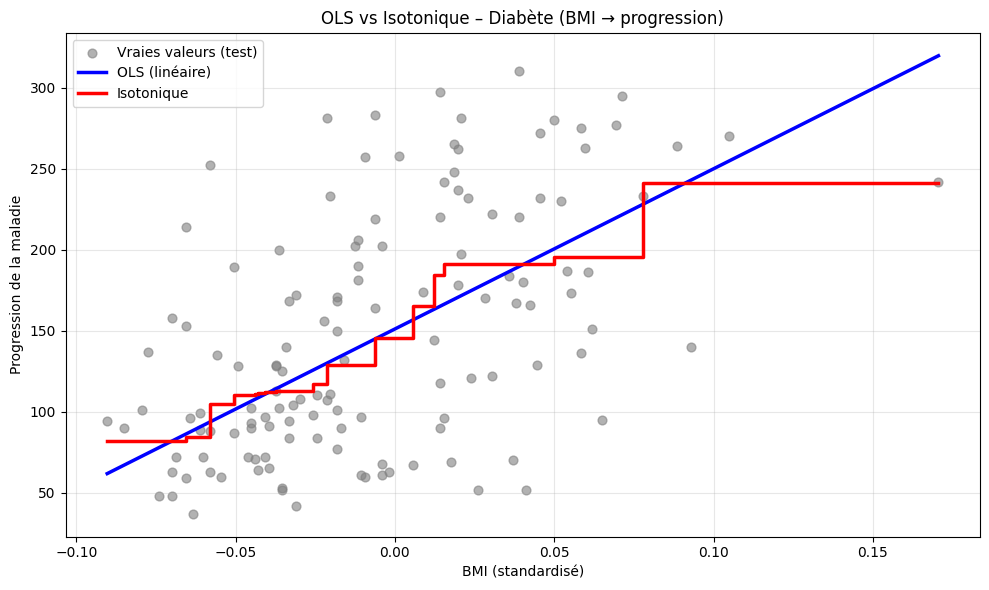

Comparaison rapide des erreurs :
RMSE : OLS = 62.3 vs Isotonique = 61.9  → Isotonique meilleur
MAE  : OLS = 50.6 vs Isotonique = 49.6   → Isotonique meilleur


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Chargement et split (BMI → target)
diabetes = load_diabetes()
X = diabetes.data[:, np.newaxis, 2]  # BMI (feature 2)
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Train : {X_train.shape[0]} exemples | Test : {X_test.shape[0]} exemples\n")

# Régression linéaire OLS
ols = LinearRegression()
ols.fit(X_train, y_train)
y_pred_ols = ols.predict(X_test)

# Métriques OLS
mse_ols  = mean_squared_error(y_test, y_pred_ols)
rmse_ols = np.sqrt(mse_ols)
mae_ols  = mean_absolute_error(y_test, y_pred_ols)
r2_ols   = r2_score(y_test, y_pred_ols)

print("Régression linéaire OLS (test set) :")
print(f"   MSE  = {mse_ols:.1f}")
print(f"   RMSE = {rmse_ols:.1f}")
print(f"   MAE  = {mae_ols:.1f}")
print(f"   R²   = {r2_ols:.3f}")
print(f"   Pente = {ols.coef_[0]:.2f} | Intercept = {ols.intercept_:.1f}\n")

# Régression isotonique (croissante)

iso = IsotonicRegression(increasing=True, out_of_bounds='clip',y_min = 0, y_max = 241)
iso.fit(X_train.ravel(), y_train)
y_pred_iso = iso.predict(X_test.ravel())

# Métriques Isotonique
mse_iso  = mean_squared_error(y_test, y_pred_iso)
rmse_iso = np.sqrt(mse_iso)
mae_iso  = mean_absolute_error(y_test, y_pred_iso)
r2_iso   = r2_score(y_test, y_pred_iso)

print("Régression isotonique (test set) :")
print(f"   MSE  = {mse_iso:.1f}")
print(f"   RMSE = {rmse_iso:.1f}")
print(f"   MAE  = {mae_iso:.1f}")
print(f"   R²   = {r2_iso:.3f}\n")

sort_idx = np.argsort(X_test.ravel())
X_plot = X_test[sort_idx].ravel()
y_true = y_test[sort_idx]
y_ols  = y_pred_ols[sort_idx]
y_iso  = y_pred_iso[sort_idx]

plt.figure(figsize=(10, 6))
plt.scatter(X_plot, y_true, color='gray', alpha=0.6, s=40, label='Vraies valeurs (test)')
plt.plot(X_plot, y_ols, color='blue', linewidth=2.5, label='OLS (linéaire)')
plt.step(X_plot, y_iso, where='post', color='red', linewidth=2.5, label='Isotonique')
plt.title("OLS vs Isotonique – Diabète (BMI → progression)")
plt.xlabel("BMI (standardisé)")
plt.ylabel("Progression de la maladie")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Bonus : comparaison des erreurs
print("Comparaison rapide des erreurs :")
print(f"RMSE : OLS = {rmse_ols:.1f} vs Isotonique = {rmse_iso:.1f}  → {'OLS meilleur' if rmse_ols < rmse_iso else 'Isotonique meilleur'}")
print(f"MAE  : OLS = {mae_ols:.1f} vs Isotonique = {mae_iso:.1f}   → {'OLS meilleur' if mae_ols < mae_iso else 'Isotonique meilleur'}")